# Analisis Bag of Words (BoW) & Regex — Aplikasi Spotify
## Alur Analisis
1. Import Library
2. Load Dataset
3. Preprocessing (Tokenisasi, Stopword, Stemming)
4. **Bag of Words — Matrix 50 Kata**
5. **BoW Positif vs Negatif**
6. **Analisis Regex — Insight Review**
7. Visualisasi & Kesimpulan

## Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import re

# NLP
import nltk
from nltk.tokenize import word_tokenize
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Sklearn untuk BoW
from sklearn.feature_extraction.text import CountVectorizer

# Download resource NLTK
nltk.download('punkt',    quiet=True)
nltk.download('punkt_tab',quiet=True)
nltk.download('stopwords',quiet=True)

# Konfigurasi tampilan
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.max_columns', 20)

available_styles = matplotlib.style.available
if 'seaborn-v0_8' in available_styles:
    plt.style.use('seaborn-v0_8')
elif 'seaborn' in available_styles:
    plt.style.use('seaborn')
else:
    plt.style.use('ggplot')

plt.rcParams['font.family'] = 'sans-serif'
print('✅ Library berhasil diimport!')

✅ Library berhasil diimport!


---
## Load Dataset

Dataset dimuat dari Directory "out".

In [2]:
# Load dataset mentah hasil scraping
file_path = '../out/rawdata_spotify_id.csv'

try:
    df = pd.read_csv(file_path, low_memory=False)
    print(f'✅ Dataset berhasil dimuat: {len(df):,} baris')
    display(df.head())
except FileNotFoundError:
    print(f'❌ File tidak ditemukan di: {file_path}')
    df = pd.DataFrame()

✅ Dataset berhasil dimuat: 482,756 baris


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,95fe611e-c2b2-435c-bba2-bd589c7d8cc6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,terima kasih Spotify sudah menyediakan lagu_lagu untuk kami,5,0,NaN,2026-04-07 13:41:34,NaN,NaN,NaN
1,2c563637-cfe6-4dcc-9b2e-1e1ab3f3883a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,👍🏼👍🏼👍🏼,5,0,9.1.32.2083,2026-04-07 13:33:14,NaN,NaN,9.1.32.2083
2,a5b1eaad-3605-4c20-b55a-1cb6bebeb857,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,sebenarnya ini tuh udah bagus banget apknya cuman tiap dengerin musik suka tiba-tiba iklan🥰.. dan itu nyebelin dan risih bgt buat gw😭🤗maaf ya devnyaa😇..,4,0,NaN,2026-04-07 13:31:21,NaN,NaN,NaN
3,05c4415f-1a32-4b31-9f75-1c8b725f3e11,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,bagus banget,5,0,NaN,2026-04-07 13:08:57,NaN,NaN,NaN
4,d5236114-519c-4502-a94f-571f5d25a9eb,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,Bagus sekali,5,0,9.1.34.2060,2026-04-07 13:00:41,NaN,NaN,9.1.34.2060


In [3]:
# Ringkasan struktur dataset
df.info()
print('\nDistribusi skor ulasan:')
print(df['score'].value_counts().sort_index())

<class 'pandas.DataFrame'>
RangeIndex: 482756 entries, 0 to 482755
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   reviewId              482756 non-null  str  
 1   userName              482756 non-null  str  
 2   userImage             482756 non-null  str  
 3   content               482741 non-null  str  
 4   score                 482756 non-null  int64
 5   thumbsUpCount         482756 non-null  int64
 6   reviewCreatedVersion  326735 non-null  str  
 7   at                    482756 non-null  str  
 8   replyContent          4903 non-null    str  
 9   repliedAt             4903 non-null    str  
 10  appVersion            326735 non-null  str  
dtypes: int64(2), str(9)
memory usage: 40.5 MB

Distribusi skor ulasan:
score
1     64388
2     17623
3     30075
4     51152
5    319518
Name: count, dtype: int64


In [4]:
# Seleksi kolom yang dibutuhkan & tangani missing values
df = df[['content', 'score', 'at']].copy()
df = df.dropna(subset=['content'])
df['content'] = df['content'].astype(str)

# Tambahkan label sentimen berdasarkan rating
df['label'] = df['score'].apply(
    lambda x: 'Positif' if x >= 4 else ('Netral' if x == 3 else 'Negatif')
)

print(f'\nJumlah data setelah seleksi: {len(df):,}')
print('\nDistribusi label sentimen:')
print(df['label'].value_counts())
display(df.head())


Jumlah data setelah seleksi: 482,741

Distribusi label sentimen:
label
Positif    370656
Negatif     82010
Netral      30075
Name: count, dtype: int64


,content,score,at,label
0,terima kasih Spotify sudah menyediakan lagu_lagu untuk kami,5,2026-04-07 13:41:34,Positif
1,👍🏼👍🏼👍🏼,5,2026-04-07 13:33:14,Positif
2,sebenarnya ini tuh udah bagus banget apknya cuman tiap dengerin musik suka tiba-tiba iklan🥰.. dan itu nyebelin dan risih bgt buat gw😭🤗maaf ya devnyaa😇..,4,2026-04-07 13:31:21,Positif
3,bagus banget,5,2026-04-07 13:08:57,Positif
4,Bagus sekali,5,2026-04-07 13:00:41,Positif


## 3. Preprocessing Teks

Tahap pra-pemrosesan dilakukan secara bertahap mengikuti pipeline standar NLP untuk bahasa Indonesia:
1. Lowercasing
2. Pembersihan karakter tidak relevan
3. Tokenisasi
4. Normalisasi slang
5. Stopword removal (Sastrawi)
6. Stemming (Sastrawi)

In [5]:
# Inisialisasi tools
factory_stop   = StopWordRemoverFactory()
factory_stem   = StemmerFactory()
sastrawi_stop  = set(factory_stop.get_stop_words())
sastrawi_stem  = factory_stem.create_stemmer()

# Kata negasi & penekanan yang tetap dipertahankan untuk analisis sentimen
kata_penting = {
    'tidak', 'bukan', 'belum', 'jangan', 'tanpa', 'kurang', 
    'susah', 'sulit', 'masalah', 'kendala', 'macet'
}

# Kamus normalisasi slang - Versi Spotify
kamus_slang = {
    # Negasi & Umum
    'ga':'tidak','gak':'tidak','gk':'tidak','ngga':'tidak','nggak':'tidak',
    'gaada':'tidak ada','gabisa':'tidak bisa','gamau':'tidak mau',
    'yg':'yang','udh':'sudah','udah':'sudah','tp':'tapi','kalo':'kalau',
    'klo':'kalau','jd':'jadi','krn':'karena','utk':'untuk','jg':'juga',
    'dr':'dari','dgn':'dengan','aja':'saja','bgt':'sekali','banget':'sekali',
    'sy':'saya','gue':'saya','gw':'saya','nih':'ini','tuh':'itu',
    
    # Istilah Aplikasi & Musik
    'apk':'aplikasi','hp':'handphone','pake':'pakai','pakek':'pakai',
    'dl':'download','updet':'perbarui','update':'perbarui',
    'prem':'premium','preman':'premium','ads':'iklan',
    'pl':'playlist','lyric':'lirik','lyrics':'lirik',
    'stel':'putar','puter':'putar','denger':'dengar',
    
    # Keluhan Teknis
    'lemot':'lambat','lelet':'lambat','eror':'error','error':'error',
    'ngebug':'bug','ngelag':'lag','macet':'lag','fc':'force close',
    'ribet':'rumit','nyesel':'menyesal',
}

# Custom stopwords domain Spotify
# Menghapus noise yang sering muncul tapi tidak membawa makna sentimen
custom_stop = [
    # Domain Music Streaming
    'aplikasi', 'spotify', 'musik', 'lagu', 'fitur', 'akun',
    'playlist', 'album', 'artis', 'penyanyi', 'audio', 'suara',
    'streaming', 'premium', 'gratis', 'free', 'iklan', 'ads',
    'lirik', 'dengar', 'putar', 'update', 'versi', 'instal',
    'online', 'offline', 'download', 'unduh',

    # Kata kerja/keterangan netral
    'tolong', 'bantu', 'pakai', 'coba', 'kasih', 'guna',
    'daftar', 'masuk', 'buka', 'data', 'pokok', 'klik',

    # Kata seru, partikel & kata ganti
    'oke', 'ok', 'ya', 'yah', 'wah', 'deh', 'dong', 'sih',
    'nih', 'tuh', 'aja', 'lagi', 'nya', 'si', 'min', 'admin', 
    'kak', 'bang', 'mas', 'mbak',

    # Simbol & residu
    '&', '.', ',', '-', '!', '?', '1', '2', '3', '4', '5', 'amp', '...',
]

# Gabungkan stopwords (dikurangi kata penting agar tidak hilang maknanya)
stopwords_gabungan = (sastrawi_stop - kata_penting) | set(custom_stop)

print(f'Total stopwords aktif: {len(stopwords_gabungan)}')

Total stopwords aktif: 868


In [6]:
# Pipeline preprocessing
def preprocessing_lengkap(teks):
    # 1. Lowercase
    teks = teks.lower()
    # 2. Hapus URL, mention, angka, simbol
    teks = re.sub(r'http\S+|www\S+', '', teks)
    teks = re.sub(r'@\w+|#\w+', '', teks)
    teks = re.sub(r'[^a-z\s]', ' ', teks)
    teks = re.sub(r'\s+', ' ', teks).strip()
    # 3. Tokenisasi
    tokens = word_tokenize(teks)
    # 4. Normalisasi slang
    tokens = [kamus_slang.get(t, t) for t in tokens]
    # Tokenisasi ulang setelah normalisasi
    tokens = ' '.join(tokens).split()
    # 5. Stopword removal
    tokens = [t for t in tokens if t not in stopwords_gabungan and len(t) > 2]
    # 6. Stemming
    kalimat = ' '.join(tokens)
    hasil_stem = sastrawi_stem.stem(kalimat)
    tokens_final = hasil_stem.split()
    return tokens_final

def teks_bersih(teks):
    return ' '.join(preprocessing_lengkap(teks))

df['tokens']        = df['content'].apply(preprocessing_lengkap)
df['content_bersih'] = df['tokens'].apply(lambda x: ' '.join(x))

# Hapus baris yang kosong setelah preprocessing
df = df[df['content_bersih'].str.strip() != ''].reset_index(drop=True)

print(f'✅ Selesai! Data setelah preprocessing: {len(df):,} baris')
display(df[['content', 'content_bersih', 'label']].head(5))

✅ Selesai! Data setelah preprocessing: 440,388 baris


,content,content_bersih,label
0,terima kasih Spotify sudah menyediakan lagu_lagu untuk kami,terima sedia,Positif
1,sebenarnya ini tuh udah bagus banget apknya cuman tiap dengerin musik suka tiba-tiba iklan🥰.. dan itu nyebelin dan risih bgt buat gw😭🤗maaf ya devnyaa😇..,bagus apknya cuman dengerin suka nyebelin risih maaf devnyaa,Positif
2,bagus banget,bagus,Positif
3,Bagus sekali,bagus,Positif
4,"FF DI HATI, hehe",hati hehe,Positif


## 4. Bag of Words (BoW)
Metode ini membantu dalam merangkum kata-kata apa saja yang paling dominan di seluruh data. Setiap ulasan akan dikonversi menjadi baris data, dan kemunculan tiap kata dicatat dalam kolom-kolom frekuensi. Kemuadian akan disaring dan menampilkan 50 kata teratas yang paling banyak dibicarakan.

In [7]:
# Bangun BoW menggunakan CountVectorizer
# max_features=50 → hanya ambil 50 kata dengan frekuensi tertinggi

vectorizer_50 = CountVectorizer(max_features=50)
matriks_bow   = vectorizer_50.fit_transform(df['content_bersih'])

kosakata_50   = vectorizer_50.get_feature_names_out()

print(f'Dimensi matriks BoW : {matriks_bow.shape}')
print(f'  → {matriks_bow.shape[0]:,} dokumen (ulasan)')
print(f'  → {matriks_bow.shape[1]} fitur (kata unik teratas)')
print(f'\n50 Kata dalam kosakata BoW:')
print(list(kosakata_50))

Dimensi matriks BoW : (440388, 50)
  → 440,388 dokumen (ulasan)
  → 50 fitur (kata unik teratas)

50 Kata dalam kosakata BoW:
['aplikasi', 'app', 'bagus', 'baguss', 'baik', 'bantu', 'banyak', 'baru', 'bayar', 'beli', 'best', 'bikin', 'bintang', 'cari', 'dah', 'dengar', 'dengerin', 'good', 'guna', 'hibur', 'iklan', 'jangan', 'jelek', 'karna', 'keren', 'kurang', 'lagu', 'langgan', 'lengkap', 'like', 'lirik', 'lumayan', 'mantap', 'mudah', 'muncul', 'music', 'musik', 'nice', 'pas', 'pilih', 'pokok', 'puas', 'putar', 'senang', 'seru', 'suka', 'susah', 'the', 'tidak', 'top']


In [8]:
# Tampilkan matriks BoW (50 dokumen pertama × 50 kata)
df_bow_matrix = pd.DataFrame(
    matriks_bow[:50].toarray(),
    columns=kosakata_50
)
df_bow_matrix.index.name = 'Dokumen'

print('=== MATRIKS BoW — 50 Dokumen × 50 Kata Teratas ===')
display(df_bow_matrix)

=== MATRIKS BoW — 50 Dokumen × 50 Kata Teratas ===


,aplikasi,app,bagus,baguss,baik,bantu,banyak,baru,bayar,beli,...,pokok,puas,putar,senang,seru,suka,susah,the,tidak,top
Dokumen,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


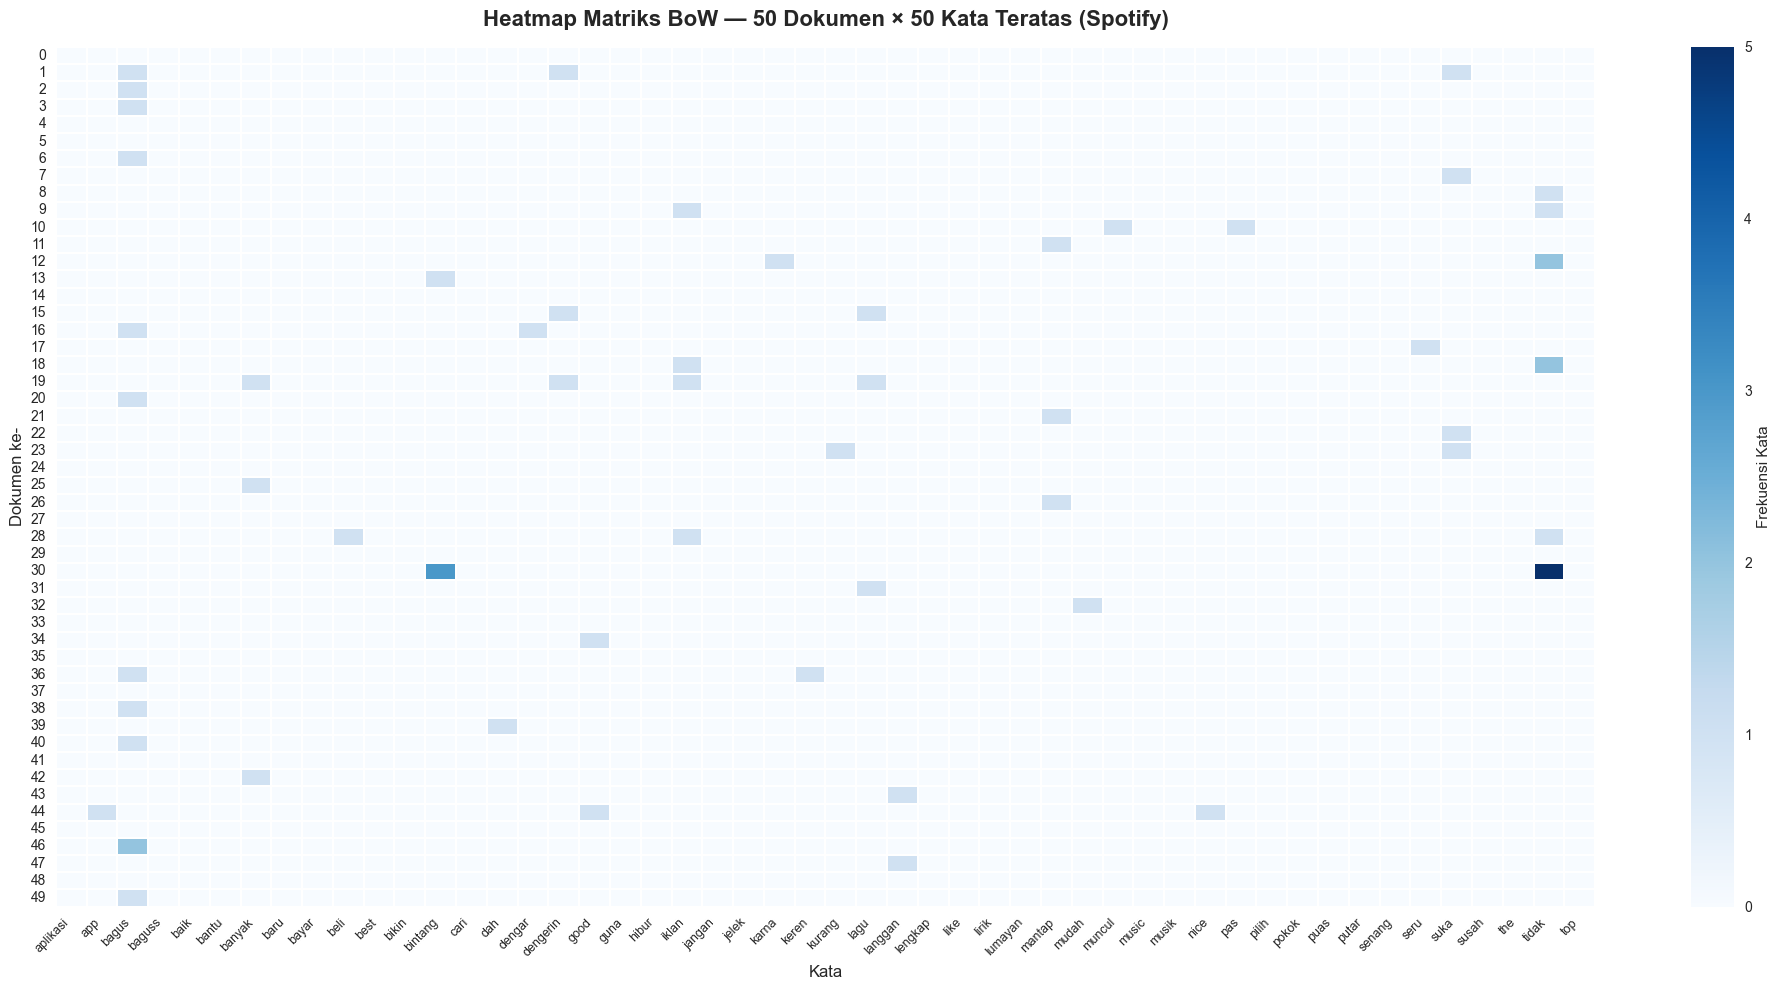

In [10]:
# Heatmap matriks BoW
plt.figure(figsize=(20, 10))
sns.heatmap(
    df_bow_matrix,
    cmap='Blues',
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Frekuensi Kata'}
)
plt.title('Heatmap Matriks BoW — 50 Dokumen × 50 Kata Teratas (Spotify)',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Kata', fontsize=12)
plt.ylabel('Dokumen ke-', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

=== FREKUENSI TOTAL 50 KATA TERATAS ===


,Kata,Frekuensi
0,bagus,98595
1,tidak,68779
2,suka,32544
3,good,27102
4,mantap,26515
5,keren,17972
6,lagu,15950
7,dengerin,13059
8,bintang,10184
9,lengkap,9723


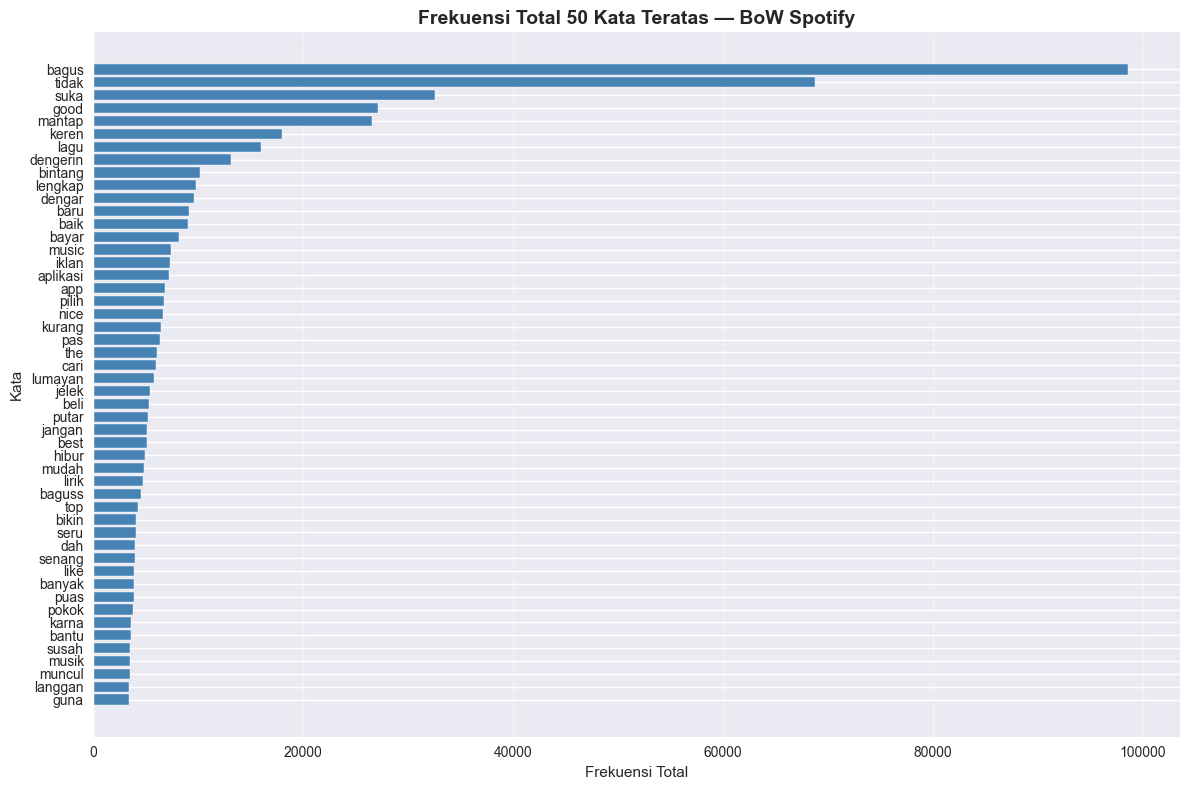

In [12]:
# Frekuensi total setiap kata dalam kosakata BoW
frekuensi_total = matriks_bow.toarray().sum(axis=0)
df_frekuensi = pd.DataFrame({
    'Kata'     : kosakata_50,
    'Frekuensi': frekuensi_total
}).sort_values('Frekuensi', ascending=False).reset_index(drop=True)

print('=== FREKUENSI TOTAL 50 KATA TERATAS ===')
display(df_frekuensi)

# Visualisasi
plt.figure(figsize=(12, 8))
plt.barh(df_frekuensi['Kata'][::-1], df_frekuensi['Frekuensi'][::-1],
         color='steelblue', edgecolor='white')
plt.title('Frekuensi Total 50 Kata Teratas — BoW Spotify',
          fontsize=14, fontweight='bold')
plt.xlabel('Frekuensi Total')
plt.ylabel('Kata')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## 5. BoW Positif vs Negatif

Analisis BoW dilakukan secara terpisah pada kelompok ulasan **Positif** (skor 4–5) dan **Negatif** (skor 1–2) untuk mengekstraksi kata-kata yang paling dominan di masing-masing kelompok sentimen.

In [13]:
# Pisahkan dataset berdasarkan label
df_positif = df[df['label'] == 'Positif'].copy()
df_negatif = df[df['label'] == 'Negatif'].copy()

print(f'Jumlah ulasan Positif : {len(df_positif):,}')
print(f'Jumlah ulasan Negatif : {len(df_negatif):,}')

Jumlah ulasan Positif : 334,743
Jumlah ulasan Negatif : 78,279


In [14]:
# BoW untuk ulasan POSITIF
vec_positif  = CountVectorizer(max_features=50)
bow_positif  = vec_positif.fit_transform(df_positif['content_bersih'])
vocab_positif = vec_positif.get_feature_names_out()

freq_positif = bow_positif.toarray().sum(axis=0)
df_bow_pos   = pd.DataFrame({
    'Kata'     : vocab_positif,
    'Frekuensi': freq_positif
}).sort_values('Frekuensi', ascending=False).reset_index(drop=True)

print('=== TOP 50 KATA — ULASAN POSITIF ===')
display(df_bow_pos)

# BoW untuk ulasan NEGATIF
vec_negatif  = CountVectorizer(max_features=50)
bow_negatif  = vec_negatif.fit_transform(df_negatif['content_bersih'])
vocab_negatif = vec_negatif.get_feature_names_out()

freq_negatif = bow_negatif.toarray().sum(axis=0)
df_bow_neg   = pd.DataFrame({
    'Kata'     : vocab_negatif,
    'Frekuensi': freq_negatif
}).sort_values('Frekuensi', ascending=False).reset_index(drop=True)

print('=== TOP 50 KATA — ULASAN NEGATIF ===')
display(df_bow_neg)

=== TOP 50 KATA — ULASAN POSITIF ===


,Kata,Frekuensi
0,bagus,86507
1,suka,26457
2,good,26291
3,mantap,25779
4,tidak,22786
5,keren,17401
6,lagu,11231
7,lengkap,8389
8,dengerin,8109
9,dengar,7668


=== TOP 50 KATA — ULASAN NEGATIF ===


,Kata,Frekuensi
0,tidak,36781
1,bagus,6421
2,bayar,4541
3,jelek,4390
4,suka,4117
5,dengerin,3911
6,baru,3814
7,beli,3249
8,lagu,3225
9,iklan,3179


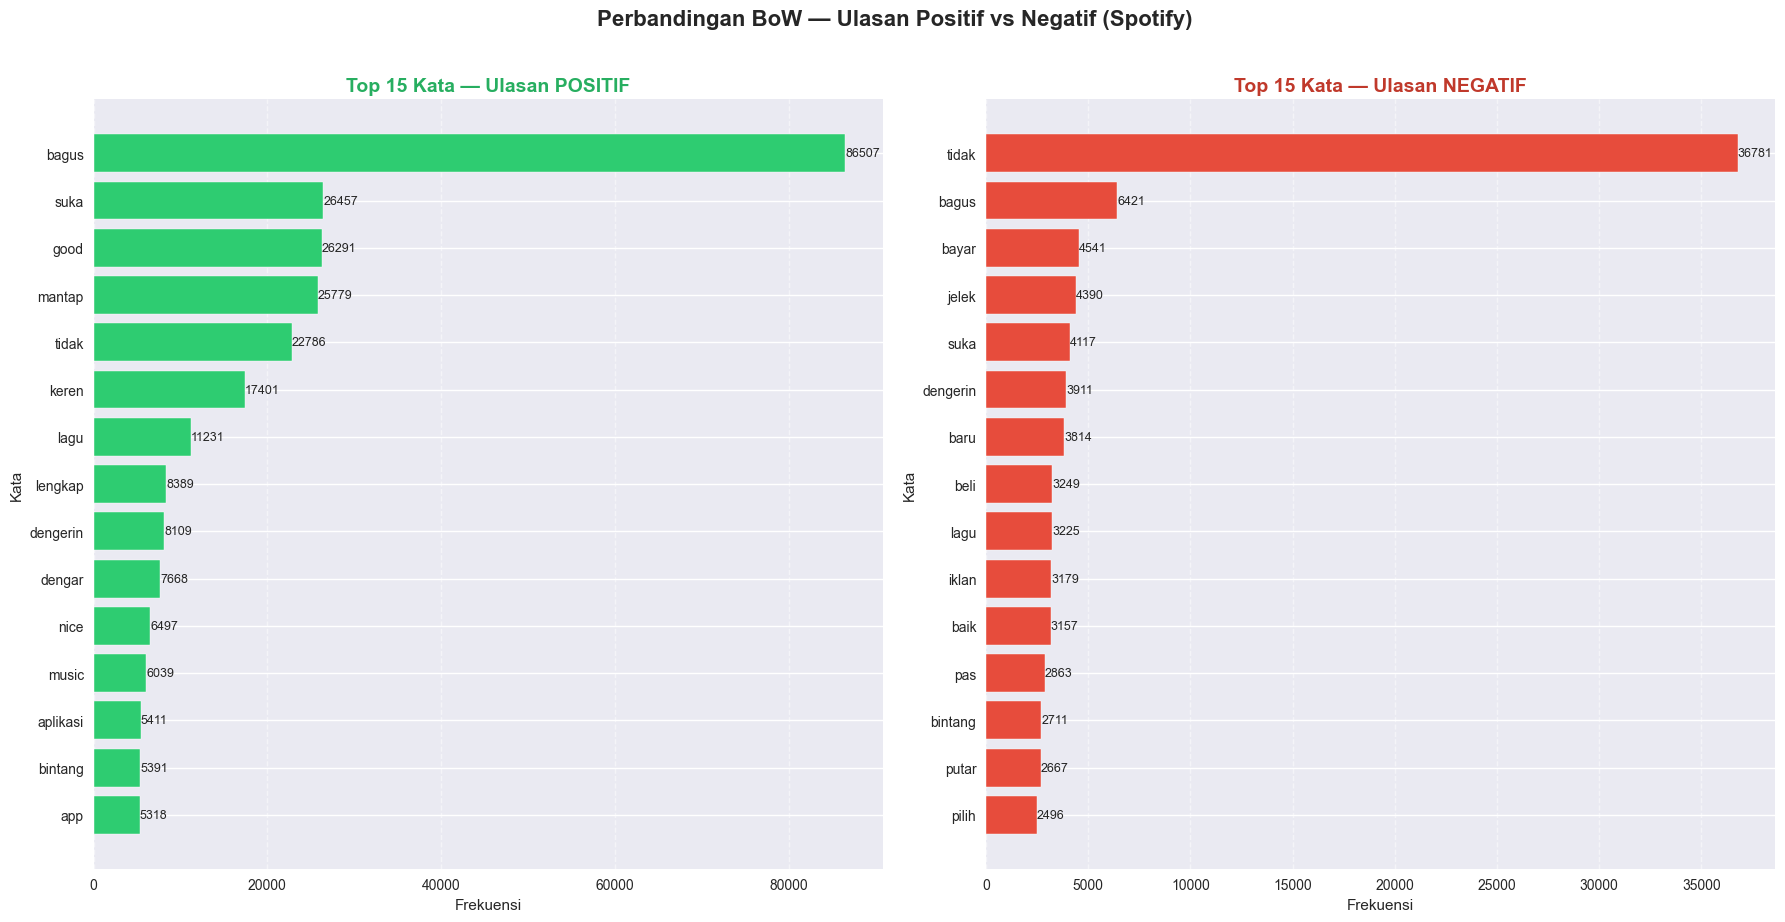

In [16]:
# Visualisasi perbandingan BoW Positif vs Negatif
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Plot Positif
top15_pos = df_bow_pos.head(15)
axes[0].barh(top15_pos['Kata'][::-1], top15_pos['Frekuensi'][::-1],
             color='#2ecc71', edgecolor='white')
axes[0].set_title('Top 15 Kata — Ulasan POSITIF', fontsize=14, fontweight='bold', color='#27ae60')
axes[0].set_xlabel('Frekuensi')
axes[0].set_ylabel('Kata')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)
for i, (kata, freq) in enumerate(zip(top15_pos['Kata'][::-1], top15_pos['Frekuensi'][::-1])):
    axes[0].text(freq + 1, i, str(freq), va='center', fontsize=9)

# Plot Negatif
top15_neg = df_bow_neg.head(15)
axes[1].barh(top15_neg['Kata'][::-1], top15_neg['Frekuensi'][::-1],
             color='#e74c3c', edgecolor='white')
axes[1].set_title('Top 15 Kata — Ulasan NEGATIF', fontsize=14, fontweight='bold', color='#c0392b')
axes[1].set_xlabel('Frekuensi')
axes[1].set_ylabel('Kata')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)
for i, (kata, freq) in enumerate(zip(top15_neg['Kata'][::-1], top15_neg['Frekuensi'][::-1])):
    axes[1].text(freq + 1, i, str(freq), va='center', fontsize=9)

plt.suptitle('Perbandingan BoW — Ulasan Positif vs Negatif (Spotify)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

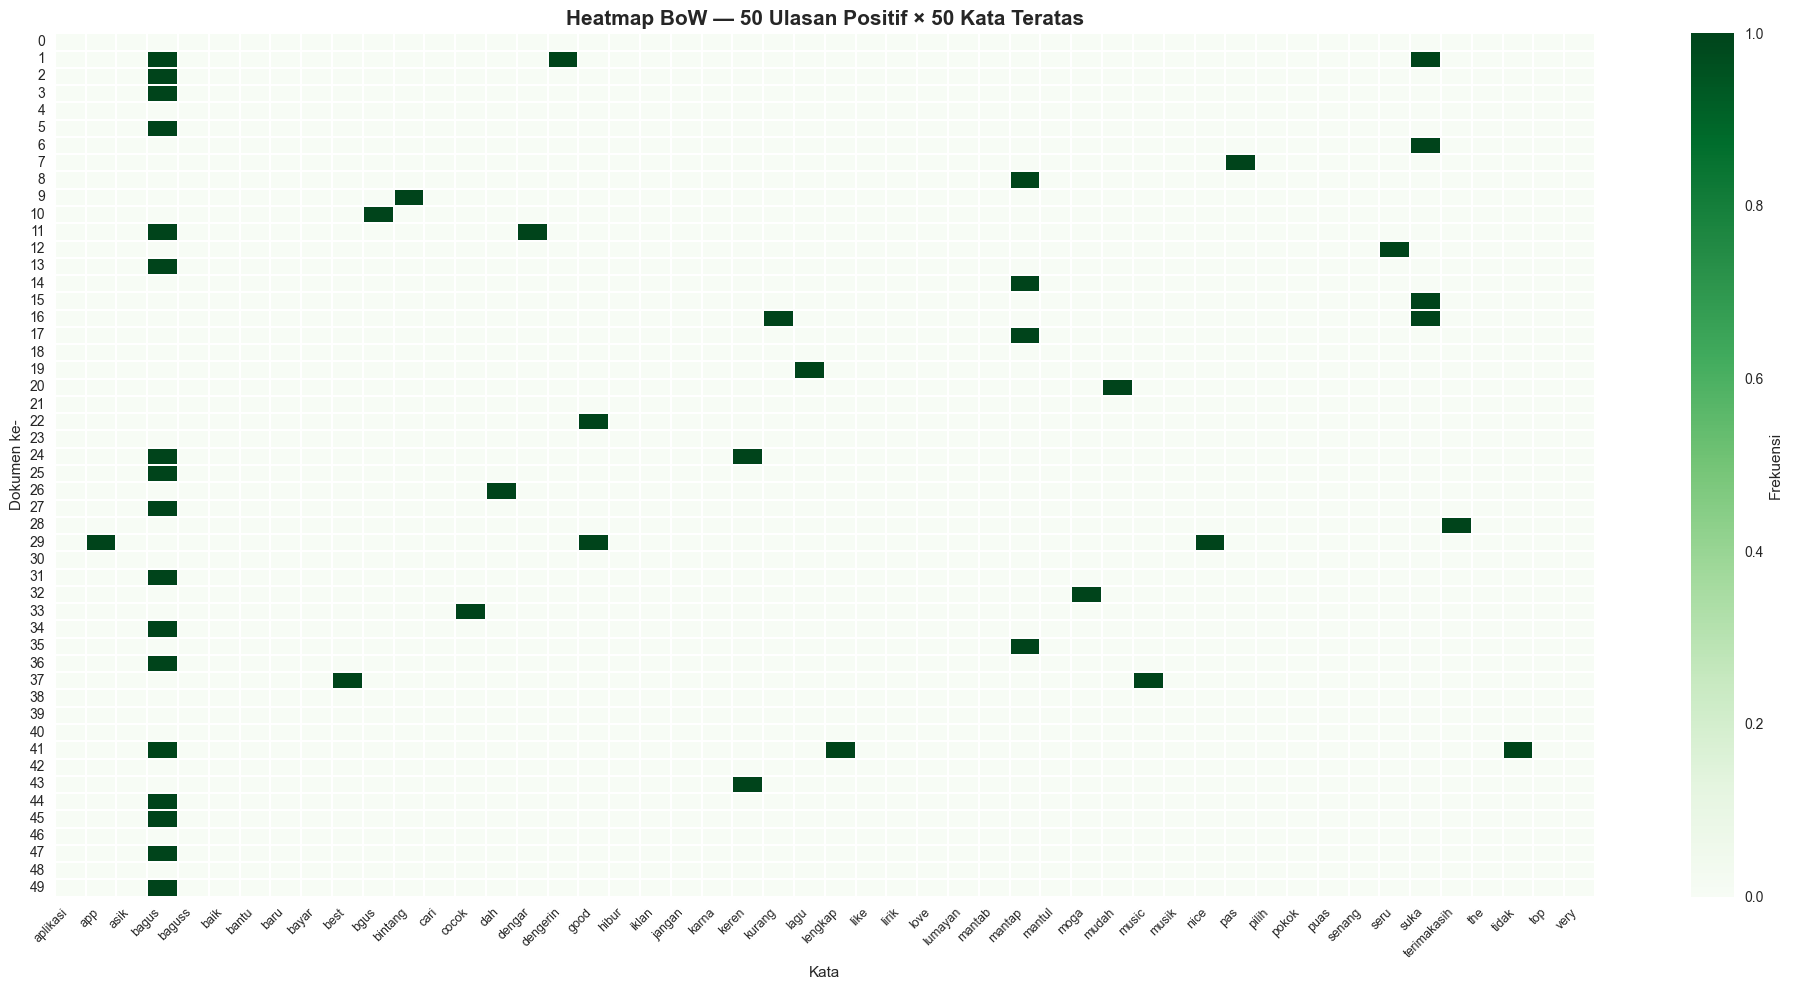

In [17]:
# Heatmap BoW 50 Dokumen Positif
df_bow_pos_matrix = pd.DataFrame(
    bow_positif[:50].toarray(),
    columns=vocab_positif
)
df_bow_pos_matrix.index.name = 'Dokumen Positif'

plt.figure(figsize=(20, 10))
sns.heatmap(df_bow_pos_matrix, cmap='Greens', linewidths=0.3,
            linecolor='white', cbar_kws={'label': 'Frekuensi'})
plt.title('Heatmap BoW — 50 Ulasan Positif × 50 Kata Teratas',
          fontsize=15, fontweight='bold')
plt.xlabel('Kata')
plt.ylabel('Dokumen ke-')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

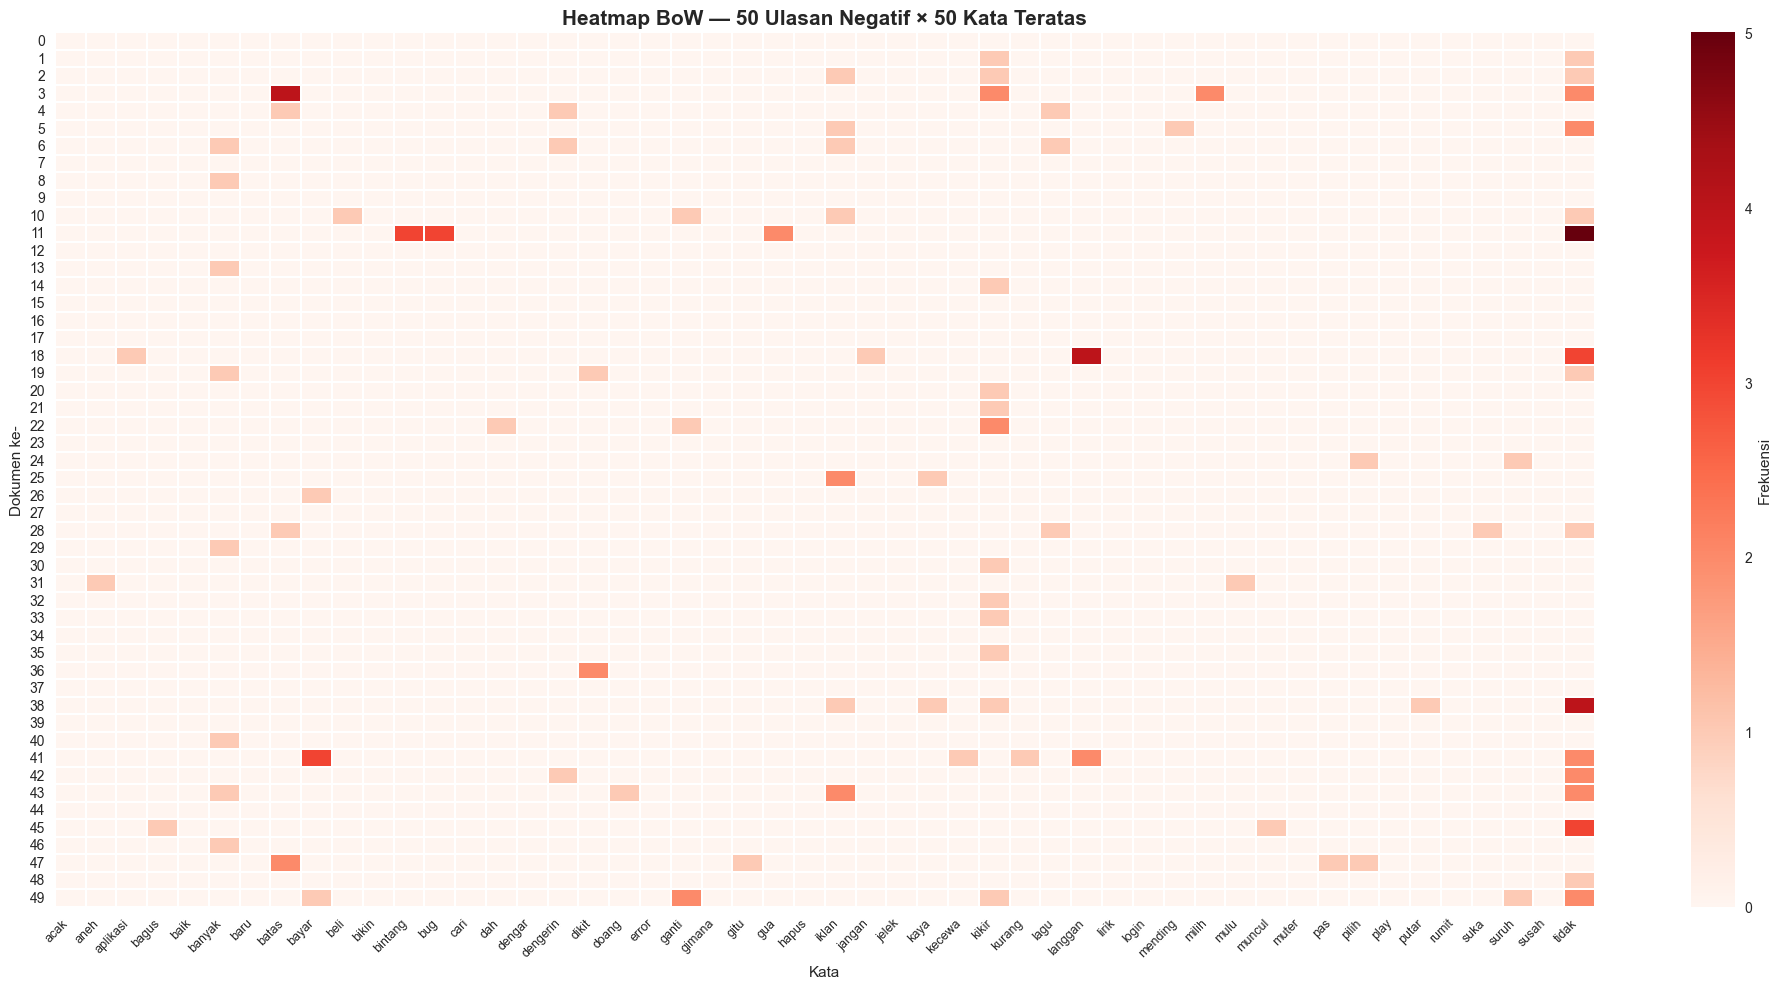

In [18]:
# Heatmap BoW 50 Dokumen Negatif
df_bow_neg_matrix = pd.DataFrame(
    bow_negatif[:50].toarray(),
    columns=vocab_negatif
)
df_bow_neg_matrix.index.name = 'Dokumen Negatif'

plt.figure(figsize=(20, 10))
sns.heatmap(df_bow_neg_matrix, cmap='Reds', linewidths=0.3,
            linecolor='white', cbar_kws={'label': 'Frekuensi'})
plt.title('Heatmap BoW — 50 Ulasan Negatif × 50 Kata Teratas',
          fontsize=15, fontweight='bold')
plt.xlabel('Kata')
plt.ylabel('Dokumen ke-')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

## 6. Analisis Regex — Ekstraksi Insight

Analisis Regex digunakan untuk mengekstraksi pola teks spesifik yang sering muncul pada ulasan, seperti keluhan fitur, masalah teknis, dan pujian pengguna.

In [19]:
pola_regex = {
    # ── Keluhan Teknis ──────────────────────────────────────────
    'Masalah Login / Akun':
        r'(?:tidak bisa|gagal|error|susah|masalah|kendala)\s+(?:login|masuk|daftar|akses)'
        r'|(?:premium.*?hilang|gagal.*?premium|langganan.*?bermasalah)'
        r'|(?:akun.*?diblokir|akun.*?keluar sendiri|log out sendiri)',

    'Aplikasi Lambat / Crash':
        r'(?:lambat|lemot|lelet|loading|hang|crash|force close|berhenti|not responding|berat|keluar sendiri|sering keluar|buffer)',

    'Pemutaran Musik Gagal':
        r'(?:lagu|musik|audio)\s+(?:tidak bisa diputar|gagal|error|berhenti sendiri|tidak ada suara|mati sendiri)'
        r'|(?:tidak bisa|gagal)\s+(?:putar|play|stel)'
        r'|(?:macet|skip sendiri|loncat sendiri)',

    'Masalah Iklan / Premium':
        r'(?:iklan|ads)\s+(?:terlalu banyak|kebanyakan|mengganggu|muncul terus|setiap lagu)'
        r'|(?:sudah|bayar)\s+premium\s+(?:tapi|masih)\s+ada\s+iklan',

    'Masalah Lirik / Download':
        r'(?:lirik|lyrics)\s+(?:tidak muncul|hilang|tidak pas|salah|error)'
        r'|(?:gagal|tidak bisa|susah)\s+(?:download|unduh|simpan|offline)',

    # ── Pujian Pengguna ─────────────────────────────────────────

    'Antarmuka Mudah / Bagus':
        r'(?:mudah|gampang|praktis|simpel|simple|user friendly|intuitif|tampilan|ui)\s+(?:bagus|keren|menarik|oke)',

    'Koleksi Lagu Lengkap':
        r'(?:lagu|musik|album|artis|playlist)\s+(?:lengkap|banyak|komplit|semua ada)'
        r'|(?:koleksi|pilihan)\s+(?:luas|lengkap|mantap)',

    'Kualitas Audio':
        r'(?:suara|audio|kualitas)\s+(?:jernih|bagus|mantap|oke|hifi|bersih)'
        r'|(?:enak)\s+(?:didengar|didengar)',

    'Fitur Rekomendasi':
        r'(?:rekomendasi|mix|daily mix|discover)\s+(?:bagus|cocok|pas|keren|mantap)'
        r'|(?:saran|algoritma)\s+(?:paham|mengerti)\s+selera',

    'Fitur Lirik / Offline':
        r'(?:lirik|lyrics)\s+(?:sangat membantu|bagus|keren|pas)'
        r'|(?:fitur|mode)\s+offline\s+(?:sangat membantu|bagus|lancar)',
}

In [20]:
# ── Terapkan pola Regex ke seluruh dataset ──────────────────────
for nama_pola, ekspresi in pola_regex.items():
    df[nama_pola] = df['content'].str.lower().str.contains(
        ekspresi, regex=True, na=False
    )

# Hitung total kemunculan setiap pola
hasil_regex = pd.DataFrame({
    'Kategori'         : list(pola_regex.keys()),
    'Total Kemunculan' : [df[nama].sum() for nama in pola_regex.keys()],
    'Tipe'             : [
        'Keluhan','Keluhan','Keluhan','Keluhan','Keluhan',
        'Pujian','Pujian','Pujian','Pujian','Pujian'
    ]
}).sort_values('Total Kemunculan', ascending=False).reset_index(drop=True)

print('=== HASIL ANALISIS REGEX ===')
display(hasil_regex)

=== HASIL ANALISIS REGEX ===


,Kategori,Total Kemunculan,Tipe
0,Aplikasi Lambat / Crash,4114,Keluhan
1,Kualitas Audio,1114,Pujian
2,Masalah Login / Akun,970,Keluhan
3,Koleksi Lagu Lengkap,969,Pujian
4,Pemutaran Musik Gagal,436,Keluhan
5,Masalah Iklan / Premium,174,Keluhan
6,Masalah Lirik / Download,172,Keluhan
7,Antarmuka Mudah / Bagus,45,Pujian
8,Fitur Lirik / Offline,42,Pujian
9,Fitur Rekomendasi,4,Pujian


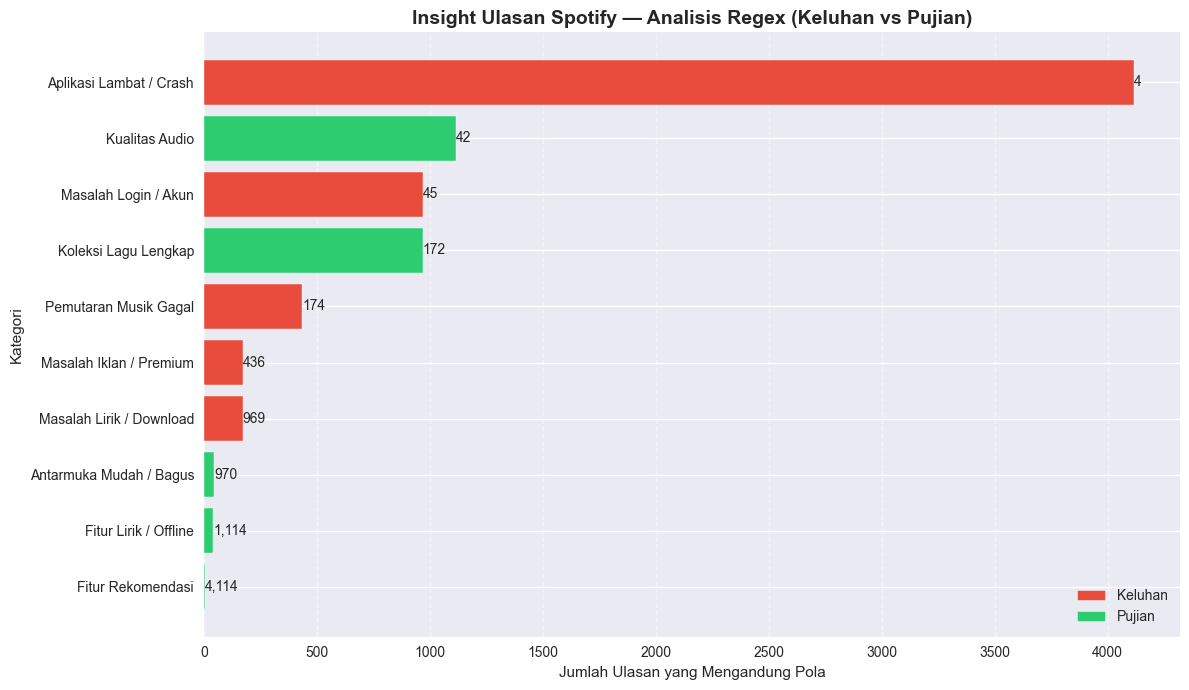

In [22]:
# Visualisasi hasil Regex
warna_map = {'Keluhan': '#e74c3c', 'Pujian': '#2ecc71'}
warna_bar = [warna_map[t] for t in hasil_regex['Tipe']]

plt.figure(figsize=(12, 7))
bars = plt.barh(
    hasil_regex['Kategori'][::-1],
    hasil_regex['Total Kemunculan'][::-1],
    color=warna_bar[::-1], edgecolor='white'
)
plt.title('Insight Ulasan Spotify — Analisis Regex (Keluhan vs Pujian)',
          fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Ulasan yang Mengandung Pola')
plt.ylabel('Kategori')
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Label nilai
for bar, val in zip(bars[::-1], hasil_regex['Total Kemunculan'][::-1]):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=10)

# Legend manual
from matplotlib.patches import Patch
legend = [Patch(color='#e74c3c', label='Keluhan'),
          Patch(color='#2ecc71', label='Pujian')]
plt.legend(handles=legend, loc='lower right')
plt.tight_layout()
plt.show()

In [23]:
# ── Contoh ulasan per kategori Regex ───────────────────────────
print('=' * 60)
for nama_pola in pola_regex.keys():
    contoh = df[df[nama_pola] == True]['content'].head(3).tolist()
    print(f'\n📌 {nama_pola} ({df[nama_pola].sum()} ulasan)')
    print('-' * 50)
    for i, ulasan in enumerate(contoh, 1):
        print(f'  {i}. {ulasan[:150]}...' if len(ulasan) > 150 else f'  {i}. {ulasan}')


📌 Masalah Login / Akun (970 ulasan)
--------------------------------------------------
  1. Saya sudah 3 tahun pengguna spotify premium, tapi kali ini saya sedikit kecewa kenapa paket berlangganan 1 tahun kok dihilangkan ? sekarang kenapa pak...
  2. saya beli akun premium untuk 3 bulan tetai belum ada 1 bulan kok premiumnya hilang. Mohon penjelasannya
  3. aplikasi sangat bagus dan simpel, tapi kalau bisa kurangi iklannya, saya tau kalau premium iklannya akan hilang tapi tolong dikurangi jadi 1-2 iklan s...

📌 Aplikasi Lambat / Crash (4114 ulasan)
--------------------------------------------------
  1. Gak suka, tiap ganti pilih musik kena limit, apa apa harus premium, pas lagi enak denger malah berhenti musik nya
  2. apalah aplikasi GK jelas bgt sat, katanya klo premium bisa denger pas ofline,tapi gw nge stuck di loading screen mulu,pdhl jaringan bagus, aslinya pen...
  3. bnyk iklan, kebelet umroh ni admin bisa GK sewajarnya iklan aja? minimal 1-2 iklan aja kocak lama lama ngelunj

## 7. Analisis Lanjutan — Regex per Sentimen

In [24]:
# Distribusi pola Regex pada ulasan Positif vs Negatif
hasil_per_label = {}
for nama_pola in pola_regex.keys():
    hasil_per_label[nama_pola] = {
        'Positif': df[(df[nama_pola]) & (df['label'] == 'Positif')].shape[0],
        'Negatif': df[(df[nama_pola]) & (df['label'] == 'Negatif')].shape[0],
    }

df_per_label = pd.DataFrame(hasil_per_label).T.reset_index()
df_per_label.columns = ['Kategori', 'Positif', 'Negatif']

print('=== DISTRIBUSI POLA REGEX PER LABEL SENTIMEN ===')
display(df_per_label)

=== DISTRIBUSI POLA REGEX PER LABEL SENTIMEN ===


,Kategori,Positif,Negatif
0,Masalah Login / Akun,157,683
1,Aplikasi Lambat / Crash,1287,2115
2,Pemutaran Musik Gagal,164,201
3,Masalah Iklan / Premium,45,108
4,Masalah Lirik / Download,48,90
5,Antarmuka Mudah / Bagus,40,3
6,Koleksi Lagu Lengkap,844,82
7,Kualitas Audio,1044,36
8,Fitur Rekomendasi,3,1
9,Fitur Lirik / Offline,30,4


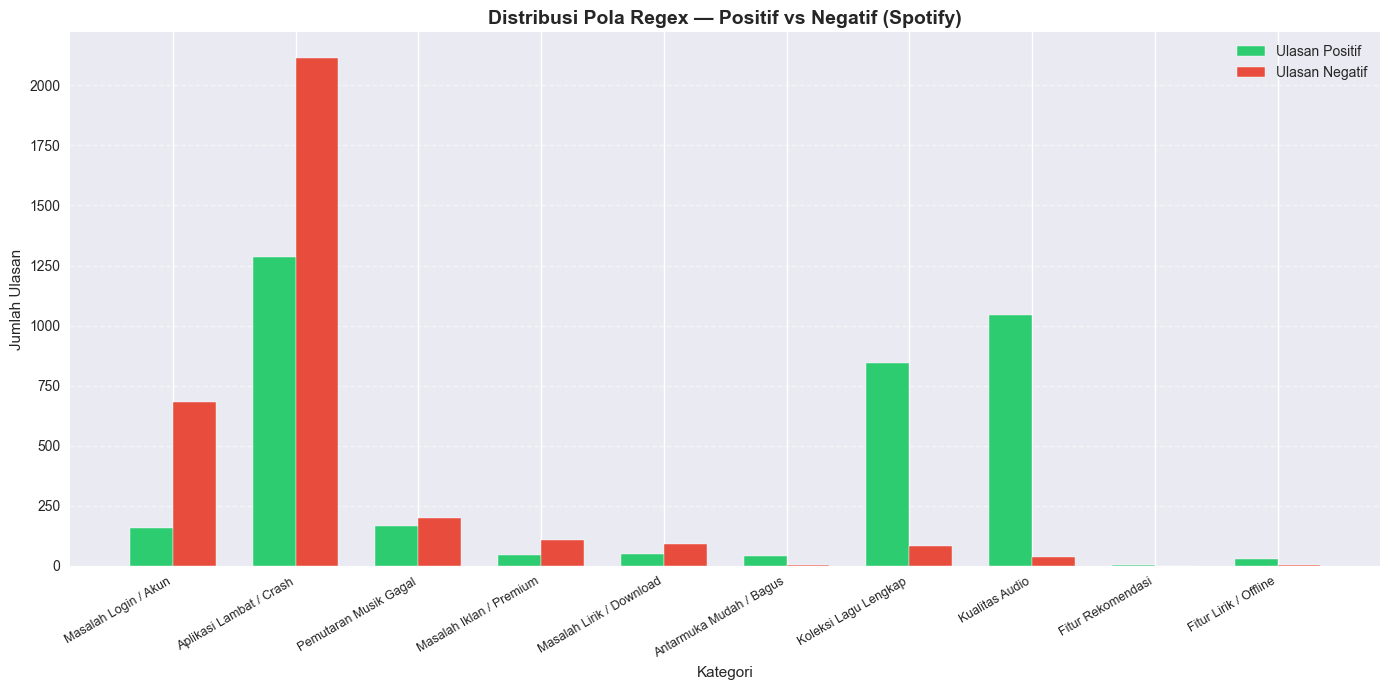

In [26]:
# Grouped bar chart Regex per sentimen
x = np.arange(len(df_per_label))
lebar = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
bar1 = ax.bar(x - lebar/2, df_per_label['Positif'], lebar,
              label='Ulasan Positif', color='#2ecc71', edgecolor='white')
bar2 = ax.bar(x + lebar/2, df_per_label['Negatif'], lebar,
              label='Ulasan Negatif', color='#e74c3c', edgecolor='white')

ax.set_title('Distribusi Pola Regex — Positif vs Negatif (Spotify)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Kategori')
ax.set_ylabel('Jumlah Ulasan')
ax.set_xticks(x)
ax.set_xticklabels(df_per_label['Kategori'], rotation=30, ha='right', fontsize=9)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 8. Ringkasan & Kesimpulan

In [27]:
# Ringkasan statistik
print('=' * 60)
print('         RINGKASAN ANALISIS BoW & REGEX — SPOTIFY')
print('=' * 60)
print(f'Total ulasan dianalisis  : {len(df):,}')
print(f'Ulasan Positif           : {len(df_positif):,} ({len(df_positif)/len(df)*100:.1f}%)')
print(f'Ulasan Negatif           : {len(df_negatif):,} ({len(df_negatif)/len(df)*100:.1f}%)')
print(f'Ukuran kosakata BoW      : 50 kata teratas')
print(f'Pola Regex diterapkan    : {len(pola_regex)} kategori')

print('\n--- TOP 5 KATA POSITIF ---')
for _, row in df_bow_pos.head(5).iterrows():
    print(f'  {row["Kata"]:<20} {row["Frekuensi"]:,}x')

print('\n--- TOP 5 KATA NEGATIF ---')
for _, row in df_bow_neg.head(5).iterrows():
    print(f'  {row["Kata"]:<20} {row["Frekuensi"]:,}x')

print('\n--- KELUHAN TERBANYAK ---')
keluhan = hasil_regex[hasil_regex['Tipe'] == 'Keluhan'].head(3)
for _, row in keluhan.iterrows():
    print(f'  {row["Kategori"]:<35} {row["Total Kemunculan"]:,} ulasan')

print('\n--- PUJIAN TERBANYAK ---')
pujian = hasil_regex[hasil_regex['Tipe'] == 'Pujian'].head(3)
for _, row in pujian.iterrows():
    print(f'  {row["Kategori"]:<35} {row["Total Kemunculan"]:,} ulasan')
print('=' * 60)

         RINGKASAN ANALISIS BoW & REGEX — SPOTIFY
Total ulasan dianalisis  : 440,388
Ulasan Positif           : 334,743 (76.0%)
Ulasan Negatif           : 78,279 (17.8%)
Ukuran kosakata BoW      : 50 kata teratas
Pola Regex diterapkan    : 10 kategori

--- TOP 5 KATA POSITIF ---
  bagus                86,507x
  suka                 26,457x
  good                 26,291x
  mantap               25,779x
  tidak                22,786x

--- TOP 5 KATA NEGATIF ---
  tidak                36,781x
  bagus                6,421x
  bayar                4,541x
  jelek                4,390x
  suka                 4,117x

--- KELUHAN TERBANYAK ---
  Aplikasi Lambat / Crash             4,114 ulasan
  Masalah Login / Akun                970 ulasan
  Pemutaran Musik Gagal               436 ulasan

--- PUJIAN TERBANYAK ---
  Kualitas Audio                      1,114 ulasan
  Koleksi Lagu Lengkap                969 ulasan
  Antarmuka Mudah / Bagus             45 ulasan


In [29]:
# ── Simpan hasil analisis ───────────────────────────────────────
df_bow_pos.to_csv('../out/bow_positif_spotify.csv', index=False, encoding='utf-8')
df_bow_neg.to_csv('../out/bow_negatif_spotify.csv', index=False, encoding='utf-8')
hasil_regex.to_csv('../out/regex_insight_spotify.csv', index=False, encoding='utf-8')

print('✅ File berhasil disimpan:')
print('   - bow_positif_spotify.csv')
print('   - bow_negatif_spotify.csv')
print('   - regex_insight_spotify.csv')

✅ File berhasil disimpan:
   - bow_positif_spotify.csv
   - bow_negatif_spotify.csv
   - regex_insight_spotify.csv
